# Upper/lower branch gap in F162M−F210M vs F360M−F480M

1. Find the boundary between the upper and lower branch with a linear SVM (self-trained, so it does not just reproduce the hand-drawn line).
2. Define each source's **offset** = signed perpendicular distance to the boundary (+ = upper branch).
3. **Test (i)**: is the gap an observational effect (missing faint F360M/F480M sources)?
4. **Test (ii)**: does the upper-branch offset correlate with physical properties expected for a disk/envelope dust excess?

Sample: same as `color_magnitude_diagram_cleancat.ipynb` (`nmatch_bands > 3`, finite F162M/F210M/F360M/F480M, `av_estimate > 12`).

In [1]:
import os
FIGDIR = '/blue/adamginsburg/t.yoo/w51_nircam/analysis/plots_for_paper/figures/branch_gap_svm_offset'
os.makedirs(FIGDIR, exist_ok=True)

import glob, pickle, warnings
warnings.filterwarnings('ignore')
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.table import Table
from astropy.io import fits
from astropy.wcs import WCS
from astroquery.svo_fps import SvoFps
from dust_extinction.averages import CT06_MWLoc
from scipy.stats import spearmanr, mannwhitneyu, pearsonr
from sklearn.svm import SVC
from sklearn.mixture import GaussianMixture

plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14

FILTERS = ['f140m', 'f162m', 'f182m', 'f187n', 'f210m', 'f335m', 'f360m', 'f405n', 'f410m', 'f480m',
           'f560w', 'f770w', 'f1000w', 'f1280w', 'f2100w']
image_filenames = {f: f"/orange/adamginsburg/jwst/w51/images/jw06151-o001_t001_nircam_clear-{f}-merged_i2d.fits"
                   for f in FILTERS if int(f[1:-1]) < 500}
image_filenames.update({f: f"/orange/adamginsburg/jwst/w51/{f.upper()}/pipeline/jw06151-o002_t001_miri_{f}_i2d.fits"
                        for f in FILTERS if int(f[1:-1]) >= 500})

catalog = Table.read('/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/catalogs/final_catalog_new_cfit_cut.fits')
catalog = catalog[catalog['nmatch_bands'] > 3]

jfilts = SvoFps.get_filter_list('JWST')
jfilts.add_index('filterID')
mag, emag = {}, {}
for f in FILTERS:
    inst = 'NIRCam' if int(f[1:-1]) < 500 else 'MIRI'
    zp = jfilts.loc[f'JWST/{inst}.{f.upper()}']['ZeroPoint']
    pix = WCS(fits.getheader(image_filenames[f], ext=('SCI', 1))).proj_plane_pixel_area().to_value(u.sr)
    flux = np.asarray(catalog['flux_fit_' + f]) * 1e6 * pix  # MJy/sr -> Jy
    eflux = np.asarray(catalog['flux_err_' + f]) * 1e6 * pix
    with np.errstate(invalid='ignore', divide='ignore'):
        mag[f] = -2.5 * np.log10(flux / zp)
        emag[f] = 2.5 / np.log(10) * np.abs(eflux / flux)
f162, f210, f360, f480 = mag['f162m'], mag['f210m'], mag['f360m'], mag['f480m']


In [2]:
# A_V from the (F162M-F210M, F162M) CMD: same linear-isochrone recipe as color_magnitude_diagram_cleancat.ipynb
parsec = Table.read('/home/t.yoo/parsec_av0.txt', format='ascii')
parsec = parsec[parsec['col4'] < 300]
dm = 5 * np.log10(5400) - 5
age_idx = parsec['col3'] == 6
iso_c = (parsec['col40'] - parsec['col42'])[age_idx]
iso_m = (parsec['col40'] + dm)[age_idx]
m_act = parsec['col6'][age_idx]
i01, i20 = np.argmin(np.abs(m_act - 0.1)), np.argmin(np.abs(m_act - 20))
m_iso = (iso_m[i20] - iso_m[i01]) / (iso_c[i20] - iso_c[i01])
b_iso = iso_m[i01] - m_iso * iso_c[i01]

ext = CT06_MWLoc()
A = {f: float(ext(1 / (int(f[1:-1]) / 100 * u.um))) for f in FILTERS}  # A_lambda / A_V
m_ext = A['f162m'] / (A['f162m'] - A['f210m'])
x_int = ((f162 - m_ext * (f162 - f210)) - b_iso) / (m_iso - m_ext)
av_estimate = (f162 - (m_iso * x_int + b_iso)) / A['f162m']
av_estimate[av_estimate < 0] = 0

xcol = f162 - f210
ycol = f360 - f480
finite4 = np.isfinite(f162) & np.isfinite(f210) & np.isfinite(f360) & np.isfinite(f480)
sample = finite4 & (av_estimate > 12)
hand_upper = sample & (ycol > 0.15 + (1.5 / 6) * xcol)
ext_slope = (A['f360m'] - A['f480m']) / (A['f162m'] - A['f210m'])  # reddening-vector slope in this CCD
print(f'N(catalog)={len(catalog)}, N(4 bands)={finite4.sum()}, N(sample, A_V>12)={sample.sum()}, '
      f'N(hand upper)={hand_upper.sum()}')
print(f'reddening vector slope in the CCD (CT06 MWLoc): {ext_slope:.3f}')


N(catalog)=15004, N(4 bands)=8003, N(sample, A_V>12)=3366, N(hand upper)=1106
reddening vector slope in the CCD (CT06 MWLoc): 0.181


## 1. SVM boundary

The branches have no external labels, so the SVM is **self-trained**: fit a linear SVM to a starting labelling, relabel every source by the SVM side, refit, and repeat until the labels stop changing. The fixed point is a max-margin line lying in the low-density gap. I test starting labellings from the hand-drawn line, from that line shifted by −0.15 … +0.2 mag, and from a 2-component 2D GMM, and vary the soft-margin parameter C.

In [3]:
X = np.column_stack([xcol[sample], ycol[sample]])

def self_train_svm(lab0, C=1.0, niter=50):
    lab = lab0.copy()
    for it in range(niter):
        clf = SVC(kernel='linear', C=C, class_weight='balanced').fit(X, lab)
        new = clf.predict(X)
        if np.array_equal(new, lab):
            break
        lab = new
    w, b = clf.coef_[0], clf.intercept_[0]
    return clf, lab, -w[0] / w[1], -b / w[1]

rows = []
lab_hand = hand_upper[sample].astype(int)
for C in [0.1, 1, 10]:
    _, lab, s, b = self_train_svm(lab_hand, C)
    rows.append((f'hand line, C={C}', s, b, lab.sum()))
for db in [-0.15, -0.1, 0.1, 0.2]:
    _, lab, s, b = self_train_svm((X[:, 1] > 0.15 + db + 0.25 * X[:, 0]).astype(int), 1)
    rows.append((f'hand line {db:+.2f} mag, C=1', s, b, lab.sum()))
gmm2d = GaussianMixture(2, covariance_type='full', n_init=20, random_state=0).fit(X)
up_comp = np.argmax(gmm2d.means_[:, 1] - 0.25 * gmm2d.means_[:, 0])
_, lab, s, b = self_train_svm((gmm2d.predict(X) == up_comp).astype(int), 1)
rows.append(('2D GMM, C=1', s, b, lab.sum()))
print(Table(rows=rows, names=['start', 'slope', 'intercept', 'N_upper'], dtype=[str, float, float, int]))

clf, lab_svm, svm_slope, svm_icpt = self_train_svm(lab_hand, C=1)
w, b0 = clf.coef_[0], clf.intercept_[0]
sgn = np.sign(w[1])
offset = sgn * (w[0] * xcol + w[1] * ycol + b0) / np.hypot(*w)   # perpendicular offset [mag], + = upper
margin = 1 / np.hypot(*w)
upper = sample & (offset > 0)
lower = sample & (offset <= 0)
print(f'adopted boundary: F360M-F480M = {svm_icpt:.3f} + {svm_slope:.3f} (F162M-F210M); '
      f'half-margin = {margin:.3f} mag; N upper = {upper.sum()}, N lower = {lower.sum()}')

# reddening-parallel alternative: 1D SVM on z = y - ext_slope*x (the E(F360M-F480M) excess at fixed A_V)
z = ycol - ext_slope * xcol
clf1d = SVC(kernel='linear', C=1, class_weight='balanced').fit(z[sample].reshape(-1, 1), lab_svm)
z0 = -clf1d.intercept_[0] / clf1d.coef_[0][0]
offset_ext = z - z0   # vertical excess above a reddening-parallel line through the gap [mag]
print(f'reddening-parallel boundary: F360M-F480M = {z0:.3f} + {ext_slope:.3f} (F162M-F210M); '
      f'labels agree with the SVM for {np.mean((offset_ext[sample] > 0) == (offset[sample] > 0)):.3f} of sources')

# empirical reddening slope: the lower branch (photospheres behind a range of A_V) traces the reddening
# direction in this CCD, so compare its slope with the SVM boundary and with extinction-law predictions
from scipy.stats import theilslopes
from dust_extinction.averages import CT06_MWGC, RL85_MWGC, G21_MWAvg, RRP89_MWGC, F11_MWGC, I05_MWAvg
lo_slope = theilslopes(ycol[lower], xcol[lower])
up_slope = theilslopes(ycol[upper], xcol[upper])
print(f'Theil-Sen slope of the lower branch: {lo_slope[0]:.3f} (95% CI {lo_slope[2]:.3f}-{lo_slope[3]:.3f}); '
      f'upper branch: {up_slope[0]:.3f} (95% CI {up_slope[2]:.3f}-{up_slope[3]:.3f}); SVM boundary: {svm_slope:.3f}')
for E in [CT06_MWLoc(), CT06_MWGC(), I05_MWAvg(), F11_MWGC(), G21_MWAvg(), RL85_MWGC(), RRP89_MWGC()]:
    a = {l: float(E(1 / (l * u.um))) for l in [1.62, 2.10, 3.60, 4.80]}
    print(f'  {type(E).__name__:>11s}: predicted reddening slope {(a[3.6] - a[4.8]) / (a[1.62] - a[2.1]):.3f}')


         start                  slope             intercept      N_upper
------------------------ ------------------- ------------------- -------
        hand line, C=0.1 0.24954612357791714 0.14068546981355068    1114
          hand line, C=1 0.24172194961890958   0.124212931168012    1168
         hand line, C=10  0.2591154051060778 0.07771220210426068    1187
hand line -0.15 mag, C=1  0.2422426492125795 0.12225758693100701    1171
hand line -0.10 mag, C=1  0.2422426492125795 0.12225758693100701    1171
hand line +0.10 mag, C=1 0.24172194961890958   0.124212931168012    1168
hand line +0.20 mag, C=1 0.24172194961890958   0.124212931168012    1168
             2D GMM, C=1 0.24172194961890958   0.124212931168012    1168
adopted boundary: F360M-F480M = 0.124 + 0.242 (F162M-F210M); half-margin = 0.072 mag; N upper = 1168, N lower = 2198
reddening-parallel boundary: F360M-F480M = 0.261 + 0.181 (F162M-F210M); labels agree with the SVM for 0.974 of sources


Theil-Sen slope of the lower branch: 0.236 (95% CI 0.231-0.241); upper branch: 0.263 (95% CI 0.251-0.273); SVM boundary: 0.242
   CT06_MWLoc: predicted reddening slope 0.181
    CT06_MWGC: predicted reddening slope 0.181
    I05_MWAvg: predicted reddening slope 0.211
     F11_MWGC: predicted reddening slope 0.128
    G21_MWAvg: predicted reddening slope 0.328
    RL85_MWGC: predicted reddening slope 0.534
   RRP89_MWGC: predicted reddening slope 0.615


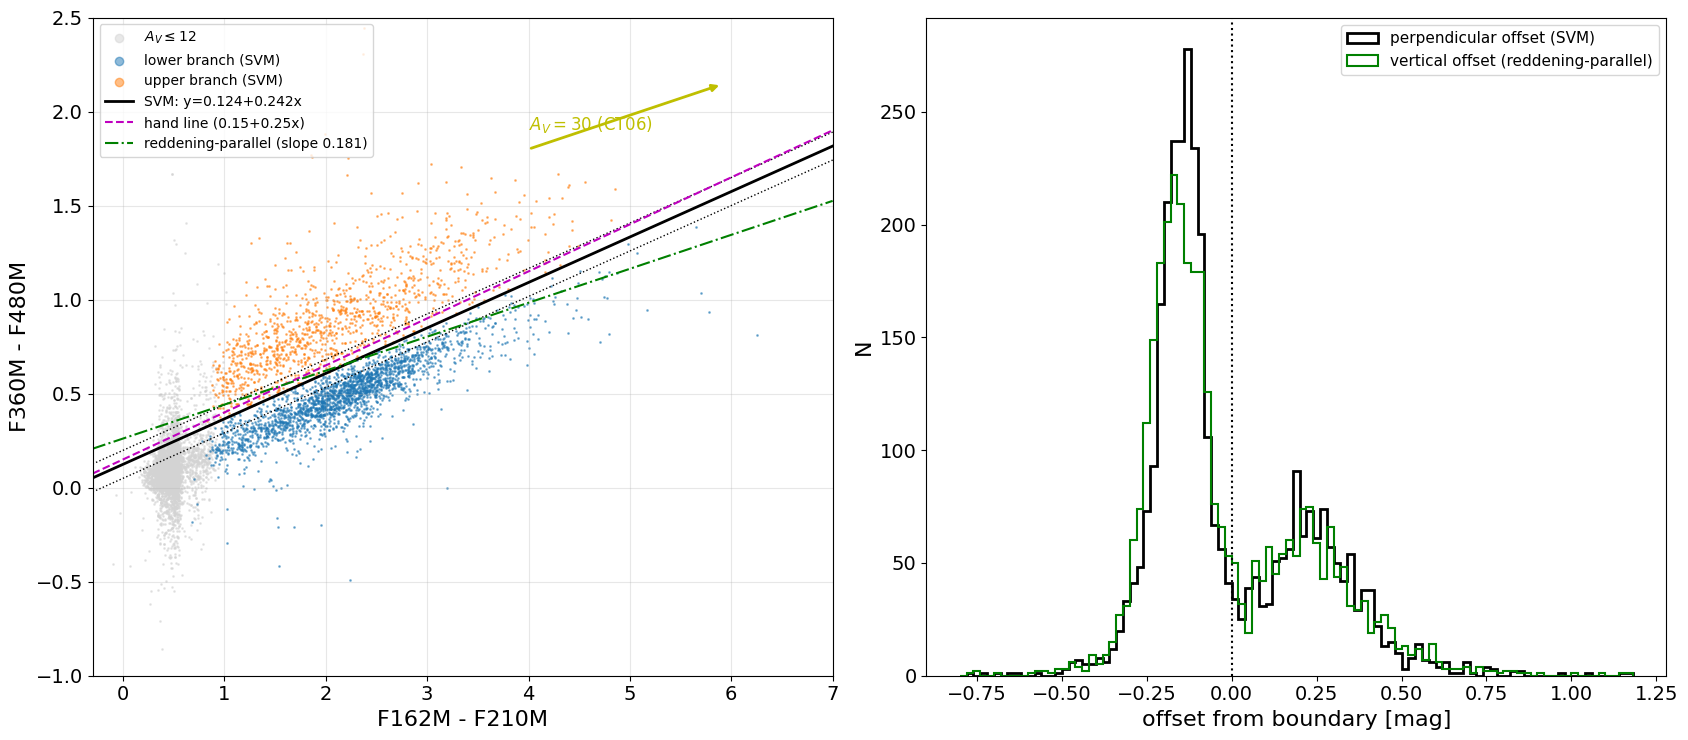

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(17, 7.5))
ax = axes[0]
ax.scatter(xcol[finite4 & ~sample], ycol[finite4 & ~sample], s=1, c='lightgray', alpha=0.5, label=r'$A_V\leq12$')
ax.scatter(xcol[lower], ycol[lower], s=1, c='tab:blue', alpha=0.5, label='lower branch (SVM)')
ax.scatter(xcol[upper], ycol[upper], s=1, c='tab:orange', alpha=0.5, label='upper branch (SVM)')
xx = np.linspace(-0.3, 7, 10)
ax.plot(xx, svm_icpt + svm_slope * xx, 'k-', lw=2, label=f'SVM: y={svm_icpt:.3f}+{svm_slope:.3f}x')
for sgn_m in [-1, 1]:
    ax.plot(xx, svm_icpt + svm_slope * xx + sgn_m * margin * np.hypot(1, svm_slope), 'k:', lw=1)
ax.plot(xx, 0.15 + 0.25 * xx, 'm--', lw=1.5, label='hand line (0.15+0.25x)')
ax.plot(xx, z0 + ext_slope * xx, 'g-.', lw=1.5, label=f'reddening-parallel (slope {ext_slope:.3f})')
ax.annotate('', xy=(4 + 30 * (A['f162m'] - A['f210m']), 1.8 + 30 * (A['f360m'] - A['f480m'])), xytext=(4, 1.8),
            arrowprops=dict(arrowstyle='-|>', color='y', lw=2))
ax.text(4, 1.9, r'$A_V=30$ (CT06)', color='y', fontsize=12)
ax.set_xlim(-0.3, 7); ax.set_ylim(-1, 2.5)
ax.set_xlabel('F162M - F210M'); ax.set_ylabel('F360M - F480M')
ax.legend(fontsize=10, markerscale=6, loc='upper left'); ax.grid(alpha=0.3)

ax = axes[1]
bins = np.arange(-0.8, 1.2, 0.02)
ax.hist(offset[sample], bins=bins, histtype='step', lw=2, color='k', label='perpendicular offset (SVM)')
ax.hist(offset_ext[sample], bins=bins, histtype='step', lw=1.5, color='g', label='vertical offset (reddening-parallel)')
ax.axvline(0, color='k', ls=':')
ax.set_xlabel('offset from boundary [mag]'); ax.set_ylabel('N'); ax.legend(fontsize=11)
plt.tight_layout(); plt.savefig(f'{FIGDIR}/branch_svm_boundary_cfit003.png', bbox_inches='tight'); plt.show()


## 2. Test (i): is the gap an observational effect?

If the gap were carved by missing faint F360M/F480M detections:
- (a) the gap should be deepest at faint magnitudes, close to the detection limits, and absent for bright sources;
- (b) the offset would correlate with F360M/F480M **inside a subsample that is complete** in both bands;
- (c) the sources lacking F360M or F480M should be numerous enough to fill the gap, and their limits should allow them to lie there.

f162m: turnover=20.88, 95th pct=23.93;  upper-branch median=21.00, lower-branch median=22.28
f210m: turnover=22.38, 95th pct=23.01;  upper-branch median=19.04, lower-branch median=19.98
f360m: turnover=19.62, 95th pct=20.82;  upper-branch median=16.67, lower-branch median=18.10
f480m: turnover=17.88, 95th pct=19.69;  upper-branch median=15.77, lower-branch median=17.60
offset vs f360m [upper]: Spearman rho=-0.244, p=2.8e-17, N=1168
offset vs f360m [lower]: Spearman rho=+0.010, p=6.3e-01, N=2198
offset vs f480m [upper]: Spearman rho=-0.332, p=1.6e-31, N=1168
offset vs f480m [lower]: Spearman rho=-0.030, p=1.7e-01, N=2198


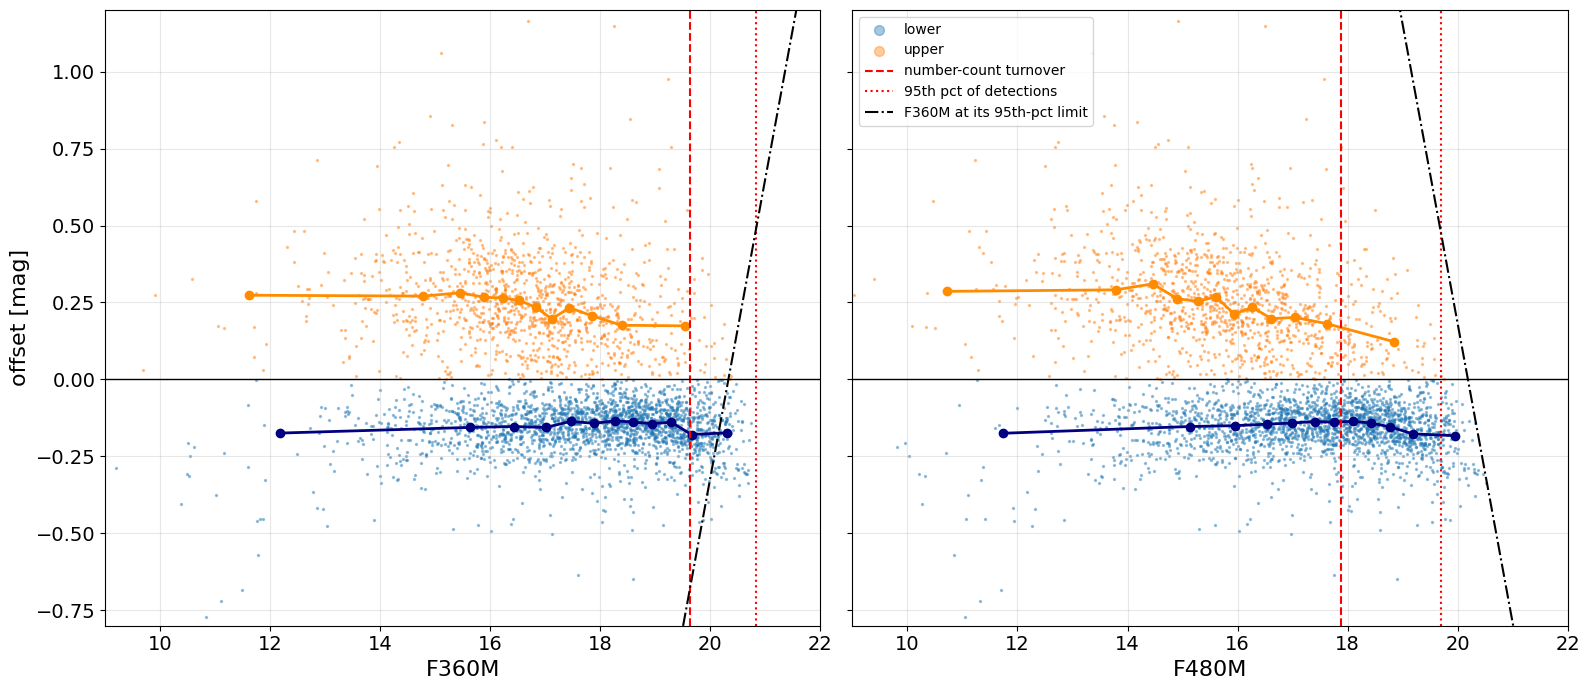

In [5]:
# detection-limit proxies: turnover (peak) and 95th percentile of the differential number counts
lims = {}
for f in ['f162m', 'f210m', 'f360m', 'f480m']:
    m = mag[f][np.isfinite(mag[f])]
    h, e = np.histogram(m, bins=np.arange(8, 30, 0.25))
    lims[f] = (e[np.argmax(h)] + 0.125, np.percentile(m, 95))
    print(f'{f}: turnover={lims[f][0]:.2f}, 95th pct={lims[f][1]:.2f};  upper-branch median={np.median(mag[f][upper]):.2f}, '
          f'lower-branch median={np.median(mag[f][lower]):.2f}')

def running_median(xv, yv, nb=12):
    q = np.nanpercentile(xv, np.linspace(0, 100, nb + 1))
    c = 0.5 * (q[1:] + q[:-1])
    med = [np.nanmedian(yv[(xv >= q[i]) & (xv < q[i + 1])]) for i in range(nb)]
    return c, np.array(med)

fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)
for ax, f in zip(axes, ['f360m', 'f480m']):
    ax.scatter(mag[f][lower], offset[lower], s=2, c='tab:blue', alpha=0.4, label='lower')
    ax.scatter(mag[f][upper], offset[upper], s=2, c='tab:orange', alpha=0.4, label='upper')
    for sel, c in [(upper, 'darkorange'), (lower, 'navy')]:
        xm, ym = running_median(mag[f][sel], offset[sel])
        ax.plot(xm, ym, '-o', c=c, lw=2)
    ax.axvline(lims[f][0], color='r', ls='--', label='number-count turnover')
    ax.axvline(lims[f][1], color='r', ls=':', label='95th pct of detections')
    # offset a source would have if the other band sat at its 95th-pct limit (median x of the sample)
    mm = np.linspace(8, 22, 100); xmed = np.median(xcol[sample])
    yv = (lims['f360m'][1] - mm) if f == 'f480m' else (mm - lims['f480m'][1])
    ax.plot(mm, sgn * (w[0] * xmed + w[1] * yv + b0) / np.hypot(*w), 'k-.', lw=1.5,
            label=('F360M at its 95th-pct limit' if f == 'f480m' else 'F480M at its 95th-pct limit'))
    for sel, lbl in [(upper, 'upper'), (lower, 'lower')]:
        r, p = spearmanr(mag[f][sel], offset[sel])
        print(f'offset vs {f} [{lbl}]: Spearman rho={r:+.3f}, p={p:.1e}, N={sel.sum()}')
    ax.set_xlabel(f.upper()); ax.axhline(0, color='k', lw=1)
    ax.set_xlim(9, 22); ax.set_ylim(-0.8, 1.2); ax.grid(alpha=0.3)
axes[0].set_ylabel('offset [mag]'); axes[1].legend(fontsize=10, markerscale=5)
plt.tight_layout(); plt.savefig(f'{FIGDIR}/branch_offset_vs_mag_cfit003.png', bbox_inches='tight'); plt.show()


 band  mag range   N  ...      Ashman D      median sigma(F360M-F480M)
----- ----------- --- ... ------------------ -------------------------
f360m  8.85-16.23 842 ...  1.666086854515779      0.013710798340068628
f360m 16.23-17.50 841 ... 2.2537311196841427       0.01602941719853319
f360m 17.50-18.73 841 ...  1.255334877781985       0.02409243012491668
f360m 18.73-20.75 842 ... 1.1154407019673314      0.047203487643679654
f480m  8.07-15.50 842 ... 2.5407439932770317      0.013875724004328559
f480m 15.50-16.89 841 ...  2.156857121090507        0.0161592206336883
f480m 16.89-18.20 841 ... 1.2082923190940211       0.02343655198861287
f480m 18.20-20.51 842 ... 0.6948086002890924       0.04672638865858402


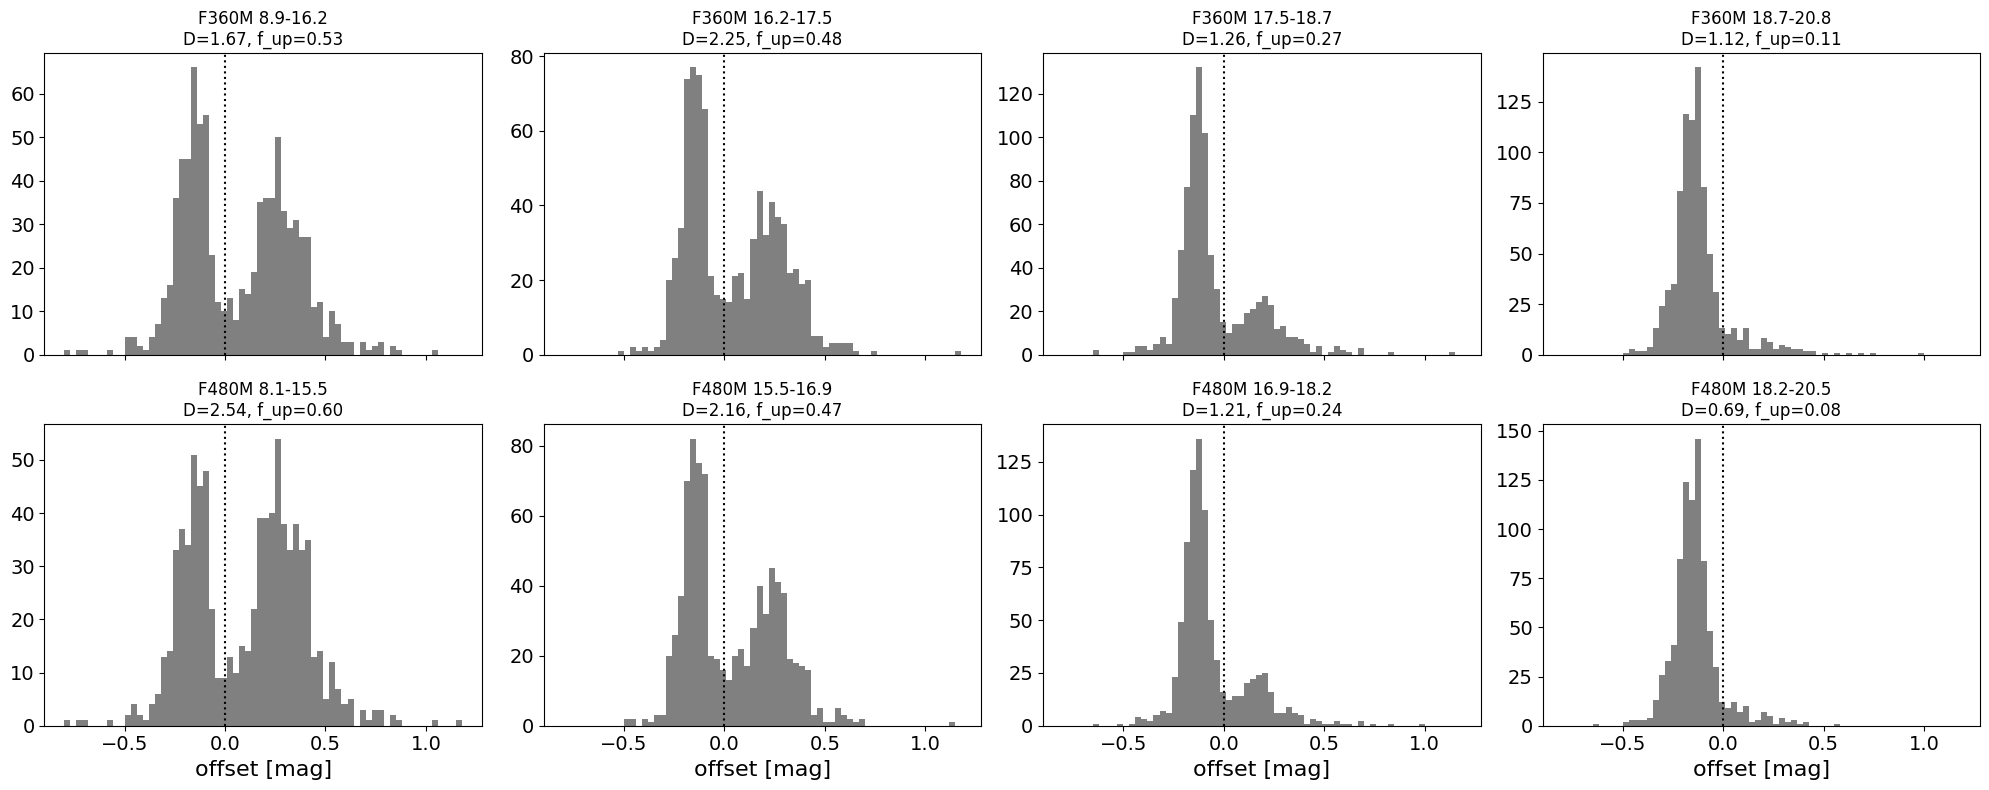

In [6]:
# (a) gap depth in magnitude quartiles: Ashman's D from a 1D 2-Gaussian fit (D > 2: clean bimodality)
def ashman_d(dd):
    g = GaussianMixture(2, n_init=10, random_state=0).fit(dd.reshape(-1, 1))
    mu, sg = g.means_.ravel(), np.sqrt(g.covariances_.ravel())
    return abs(mu[0] - mu[1]) / np.sqrt((sg[0]**2 + sg[1]**2) / 2)

sigc = np.hypot(emag['f360m'], emag['f480m'])
fig, axes = plt.subplots(2, 4, figsize=(20, 8), sharex=True)
rows = []
for r_i, f in enumerate(['f360m', 'f480m']):
    q = np.nanpercentile(mag[f][sample], [0, 25, 50, 75, 100])
    for i in range(4):
        m = sample & (mag[f] >= q[i]) & (mag[f] <= q[i + 1])
        D = ashman_d(offset[m])
        rows.append((f, f'{q[i]:.2f}-{q[i+1]:.2f}', m.sum(), np.mean(offset[m] > 0), D, np.nanmedian(sigc[m])))
        ax = axes[r_i, i]
        ax.hist(offset[m], bins=np.arange(-0.8, 1.2, 0.03), color='gray')
        ax.axvline(0, color='k', ls=':')
        ax.set_title(f'{f.upper()} {q[i]:.1f}-{q[i+1]:.1f}\nD={D:.2f}, f_up={np.mean(offset[m] > 0):.2f}', fontsize=12)
for ax in axes[1]:
    ax.set_xlabel('offset [mag]')
print(Table(rows=rows, names=['band', 'mag range', 'N', 'frac upper', "Ashman D", 'median sigma(F360M-F480M)'],
            dtype=[str, str, int, float, float, float]))
plt.tight_layout(); plt.savefig(f'{FIGDIR}/branch_offset_hist_magbins_cfit003.png', bbox_inches='tight'); plt.show()


In [7]:
# (b) complete subsample: any source with -0.3 < F360M-F480M < 1.5 and F480M below the cut has F360M
# brighter than the F360M turnover, so neither band's limit truncates the offset distribution there
f480_cut = lims['f360m'][0] - 1.5
comp = sample & (f480 < f480_cut) & (f360 < lims['f360m'][0])
print(f'complete subsample: F480M < {f480_cut:.2f} and F360M < {lims["f360m"][0]:.2f}: N={comp.sum()}, '
      f'N upper={np.sum(comp & upper)}, Ashman D={ashman_d(offset[comp]):.2f}')
for f in ['f162m', 'f210m', 'f360m', 'f480m']:
    r, p = spearmanr(mag[f][comp & upper], offset[comp & upper])
    print(f'  upper, complete: offset vs {f}: rho={r:+.3f}, p={p:.1e}')
# the F480M dependence is partly built in: F480M = F360M - (F360M-F480M); correlate against F360M
# after removing the offset's own contribution, i.e. the mag a source would have on the boundary
f480_on_boundary = f480 + (offset * np.hypot(1, svm_slope))  # y shift to reach the boundary at fixed x
r, p = spearmanr(f480_on_boundary[comp & upper], offset[comp & upper])
print(f'  upper, complete: offset vs F480M projected onto the boundary: rho={r:+.3f}, p={p:.1e}')


complete subsample: F480M < 18.12 and F360M < 19.62: N=2475, N upper=1094, Ashman D=1.66
  upper, complete: offset vs f162m: rho=+0.017, p=5.8e-01
  upper, complete: offset vs f210m: rho=-0.043, p=1.6e-01
  upper, complete: offset vs f360m: rho=-0.197, p=5.0e-11
  upper, complete: offset vs f480m: rho=-0.297, p=8.7e-24
  upper, complete: offset vs F480M projected onto the boundary: rho=-0.205, p=8.6e-12


In [8]:
# (c) sources that are detected in F162M/F210M with A_V>12 but lack F360M and/or F480M
base = np.isfinite(f162) & np.isfinite(f210) & (av_estimate > 12)
miss480 = base & np.isfinite(f360) & ~np.isfinite(f480)
miss360 = base & ~np.isfinite(f360) & np.isfinite(f480)
missboth = base & ~np.isfinite(f360) & ~np.isfinite(f480)
print(f'A_V>12 sources with F162M+F210M: {base.sum()}; missing only F480M: {miss480.sum()}, '
      f'only F360M: {miss360.sum()}, both: {missboth.sum()}')

def perp(xv, yv):
    return sgn * (w[0] * xv + w[1] * yv + b0) / np.hypot(*w)

gap_half = 0.05
for lbl, lim in [('turnover', lims['f480m'][0]), ('95th pct', lims['f480m'][1])]:
    dmax = perp(xcol[miss480], f360[miss480] - lim)          # F480M fainter than lim -> offset < dmax
    print(f'missing F480M, limit at {lbl} ({lim:.2f}): {np.sum(dmax > -gap_half)} of {miss480.sum()} could reach the gap')
for lbl, lim in [('turnover', lims['f360m'][0]), ('95th pct', lims['f360m'][1])]:
    dmin = perp(xcol[miss360], lim - f480[miss360])          # F360M fainter than lim -> offset > dmin
    print(f'missing F360M, limit at {lbl} ({lim:.2f}): {np.sum(dmin < gap_half)} of {miss360.sum()} could reach the gap')

# how many sources would be needed to fill the gap: linear bridge between the two histogram peaks
h, e = np.histogram(offset[sample], bins=np.arange(-0.6, 0.8, 0.02)); c = 0.5 * (e[1:] + e[:-1])
il, iu = np.argmax(np.where(c < 0, h, -1)), np.argmax(np.where(c > 0, h, -1))
between = (c > c[il]) & (c < c[iu])
deficit = np.sum(np.interp(c[between], [c[il], c[iu]], [h[il], h[iu]]) - h[between])
print(f'histogram peaks at offset {c[il]:+.2f} and {c[iu]:+.2f}; sources needed to fill the gap to a linear bridge: '
      f'{deficit:.0f}; all missing-band sources combined: {(miss480 | miss360 | missboth).sum()}')


A_V>12 sources with F162M+F210M: 3842; missing only F480M: 237, only F360M: 41, both: 198
missing F480M, limit at turnover (17.88): 165 of 237 could reach the gap
missing F480M, limit at 95th pct (19.69): 98 of 237 could reach the gap
missing F360M, limit at turnover (19.62): 7 of 41 could reach the gap
missing F360M, limit at 95th pct (20.82): 1 of 41 could reach the gap
histogram peaks at offset -0.13 and +0.19; sources needed to fill the gap to a linear bridge: 1704; all missing-band sources combined: 476


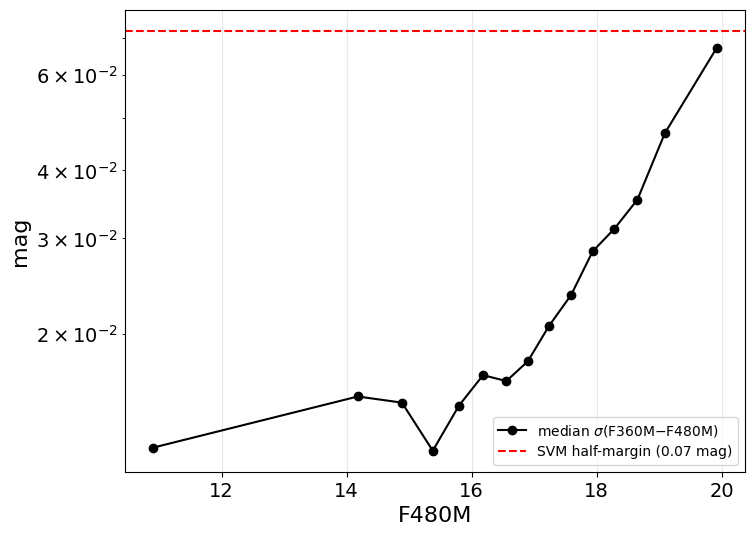

In [9]:
# photometric noise vs gap width: noise fills a gap; it cannot open one
fig, ax = plt.subplots(figsize=(8, 6))
xm, ym = running_median(f480[sample], sigc[sample], 15)
ax.plot(xm, ym, 'k-o', label=r'median $\sigma$(F360M$-$F480M)')
ax.axhline(margin, color='r', ls='--', label=f'SVM half-margin ({margin:.2f} mag)')
ax.set_xlabel('F480M'); ax.set_ylabel('mag'); ax.set_yscale('log'); ax.legend(); ax.grid(alpha=0.3)
plt.savefig(f'{FIGDIR}/branch_color_error_vs_gap_cfit003.png', bbox_inches='tight'); plt.show()


## 3. Test (ii): offset vs properties of upper-branch sources

Working hypothesis: offset = dust excess at 4.8 µm relative to 3.6 µm from a disk/envelope. Expectations if true:
- redder MIRI colors (F480M−F560W, F560W−F770W, F480M−F2100W) and a redder dereddened F210M−F360M (hot inner-disk excess) with larger offset;
- worse star-only (photosphere + extinction) SED fits with larger offset;
- larger offset for Robitaille (2017) best-fit geometries that include an envelope;
- possibly stronger accretion tracers (Paα: F187N−F182M; Brα: F405N−F410M; negative = line emission). Pfβ (4.65 µm), CO fundamental and H₂ lines also fall in F480M and could raise the offset without dust.

The lower branch runs parallel to the SVM boundary (Theil–Sen slope ≈0.24, section 1), while the CT06 law predicts 0.181. Taking the lower branch as the empirical reddening direction, the perpendicular offset is close to extinction-independent. The `rho_ext` column uses the CT06 reddening-parallel excess instead and shows how the conclusions depend on the assumed extinction law; with a CT06 slope shallower than the data, that excess picks up an artificial A_V dependence. `rho_perp|AV` is the partial Spearman correlation controlling for A_V. The narrowband colors are dereddened with CT06 (the correction is small).

In [10]:
sed_dir = '/orange/adamginsburg/w51/TaehwaYoo/jwst_w51/sed_fitting'
chi = {}
for fn in glob.glob(f'{sed_dir}/reduced_chi2_staronly_upper_*.pkl') + glob.glob(f'{sed_dir}/reduced_chi2_staronly_lower_*.pkl'):
    with open(fn, 'rb') as fh:
        chi.update(pickle.load(fh))
geo = {}
for fn in glob.glob(f'{sed_dir}/best_geos_r17_upper_*.pkl') + glob.glob(f'{sed_dir}/best_geos_r17_lower_*.pkl'):
    with open(fn, 'rb') as fh:
        geo.update(pickle.load(fh))
n = len(catalog)
log_rchi2 = np.full(n, np.nan); t_star = np.full(n, np.nan); av_sed = np.full(n, np.nan)
for k, v in chi.items():
    log_rchi2[k] = np.log10(v['reduced_chi2']); t_star[k] = v['star_temperature']; av_sed[k] = v['av']
geom = np.array([geo.get(k, '') for k in range(n)])
has_env = np.array([len(g) == 7 and g[2] in 'pu' for g in geom])
has_disk = np.array([len(g) == 7 and g[1] == 'p' for g in geom])
has_cav = np.array([len(g) == 7 and g[3] == 'b' for g in geom])
has_geo = geom != ''
print(f'star-only fits: {np.isfinite(log_rchi2[upper]).sum()} of {upper.sum()} upper-branch sources; '
      f'geometry: {has_geo[upper].sum()}')

# 870 um ATLASGAL intensity at each source (21" beam): environment / gas column tracer
ag = fits.open('/orange/adamginsburg/galactic_plane_surveys/atlasgal/PLANCK/FITS/AG-Laboca-Planck.49.5.fits')[0]
ag_wcs = WCS(ag.header).celestial
sc = catalog['skycoord_ref']
px, py = ag_wcs.world_to_pixel(sc.galactic)
s870 = ag.data[np.clip(np.round(py).astype(int), 0, ag.data.shape[0] - 1),
               np.clip(np.round(px).astype(int), 0, ag.data.shape[1] - 1)]

def dered(c1, c2):
    return mag[c1] - mag[c2] - av_estimate * (A[c1] - A[c2])

props = {
    r'$A_V$ (F162M$-$F210M)': av_estimate,
    r'(F210M)$_0$ [luminosity proxy]': f210 - av_estimate * A['f210m'],
    r'(F210M$-$F360M)$_0$': dered('f210m', 'f360m'),
    r'(F480M$-$F560W)$_0$': dered('f480m', 'f560w'),
    r'(F560W$-$F770W)$_0$': dered('f560w', 'f770w'),
    r'(F480M$-$F2100W)$_0$': dered('f480m', 'f2100w'),
    r'(F187N$-$F182M)$_0$ (Pa$\alpha$)': dered('f187n', 'f182m'),
    r'(F405N$-$F410M)$_0$ (Br$\alpha$)': dered('f405n', 'f410m'),
    r'log $\chi^2_\nu$ star-only SED': log_rchi2,
    r'$T_\star$ star-only SED [K]': t_star,
    r'log S$_{870}$ [Jy/beam]': np.log10(np.where(s870 > 0, s870, np.nan)),
    'log F480M local bkg': np.log10(np.where(np.asarray(catalog['local_bkg_f480m']) > 0, np.asarray(catalog['local_bkg_f480m']), np.nan)),
    'F480M sharpness': np.asarray(catalog['sharpness_f480m']),
    'F480M cfit': np.asarray(catalog['cfit_f480m']),
}

def partial_spearman(xv, yv, cv):
    from scipy.stats import rankdata
    rx, ry, rc = rankdata(xv), rankdata(yv), rankdata(cv)
    ex = rx - np.polyval(np.polyfit(rc, rx, 1), rc)
    ey = ry - np.polyval(np.polyfit(rc, ry, 1), rc)
    return pearsonr(ex, ey)

rows = []
for name, v in props.items():
    m = upper & np.isfinite(v)
    if m.sum() < 20:
        continue
    r1, p1 = spearmanr(v[m], offset[m])
    r2, p2 = spearmanr(v[m], offset_ext[m])
    r3, p3 = partial_spearman(v[m], offset[m], av_estimate[m])
    rows.append((name, m.sum(), r1, p1, r2, p2, r3, p3))
res = Table(rows=rows, names=['property', 'N', 'rho_perp', 'p_perp', 'rho_ext', 'p_ext', 'rho_perp|AV', 'p_perp|AV'],
            dtype=[str, int] + [float] * 6)
for c in res.colnames[2:]:
    res[c].format = '.3f' if c.startswith('rho') else '.1e'
print(f'Bonferroni threshold for {len(res)} properties at alpha=0.01: p < {0.01 / len(res):.1e}')
res.pprint(max_width=-1)


star-only fits: 1146 of 1168 upper-branch sources; geometry: 1147
Bonferroni threshold for 13 properties at alpha=0.01: p < 7.7e-04
            property              N   rho_perp  p_perp rho_ext  p_ext  rho_perp|AV p_perp|AV
-------------------------------- ---- -------- ------- ------- ------- ----------- ---------
           $A_V$ (F162M$-$F210M) 1168    0.122 3.0e-05   0.410 1.5e-48       0.007   8.2e-01
  (F210M)$_0$ [luminosity proxy] 1168   -0.183 2.7e-10  -0.337 1.8e-32      -0.139   1.8e-06
             (F210M$-$F360M)$_0$ 1168    0.392 2.6e-44   0.260 1.8e-19       0.458   9.0e-62
             (F480M$-$F560W)$_0$  616    0.104 9.8e-03   0.073 7.0e-02       0.109   6.7e-03
             (F560W$-$F770W)$_0$  214    0.152 2.6e-02   0.113 9.9e-02       0.168   1.4e-02
(F187N$-$F182M)$_0$ (Pa$\alpha$) 1009   -0.049 1.2e-01   0.053 9.0e-02      -0.101   1.3e-03
(F405N$-$F410M)$_0$ (Br$\alpha$) 1060   -0.064 3.7e-02  -0.185 1.3e-09      -0.013   6.8e-01
  log $\chi^2_\nu$ star-only SE

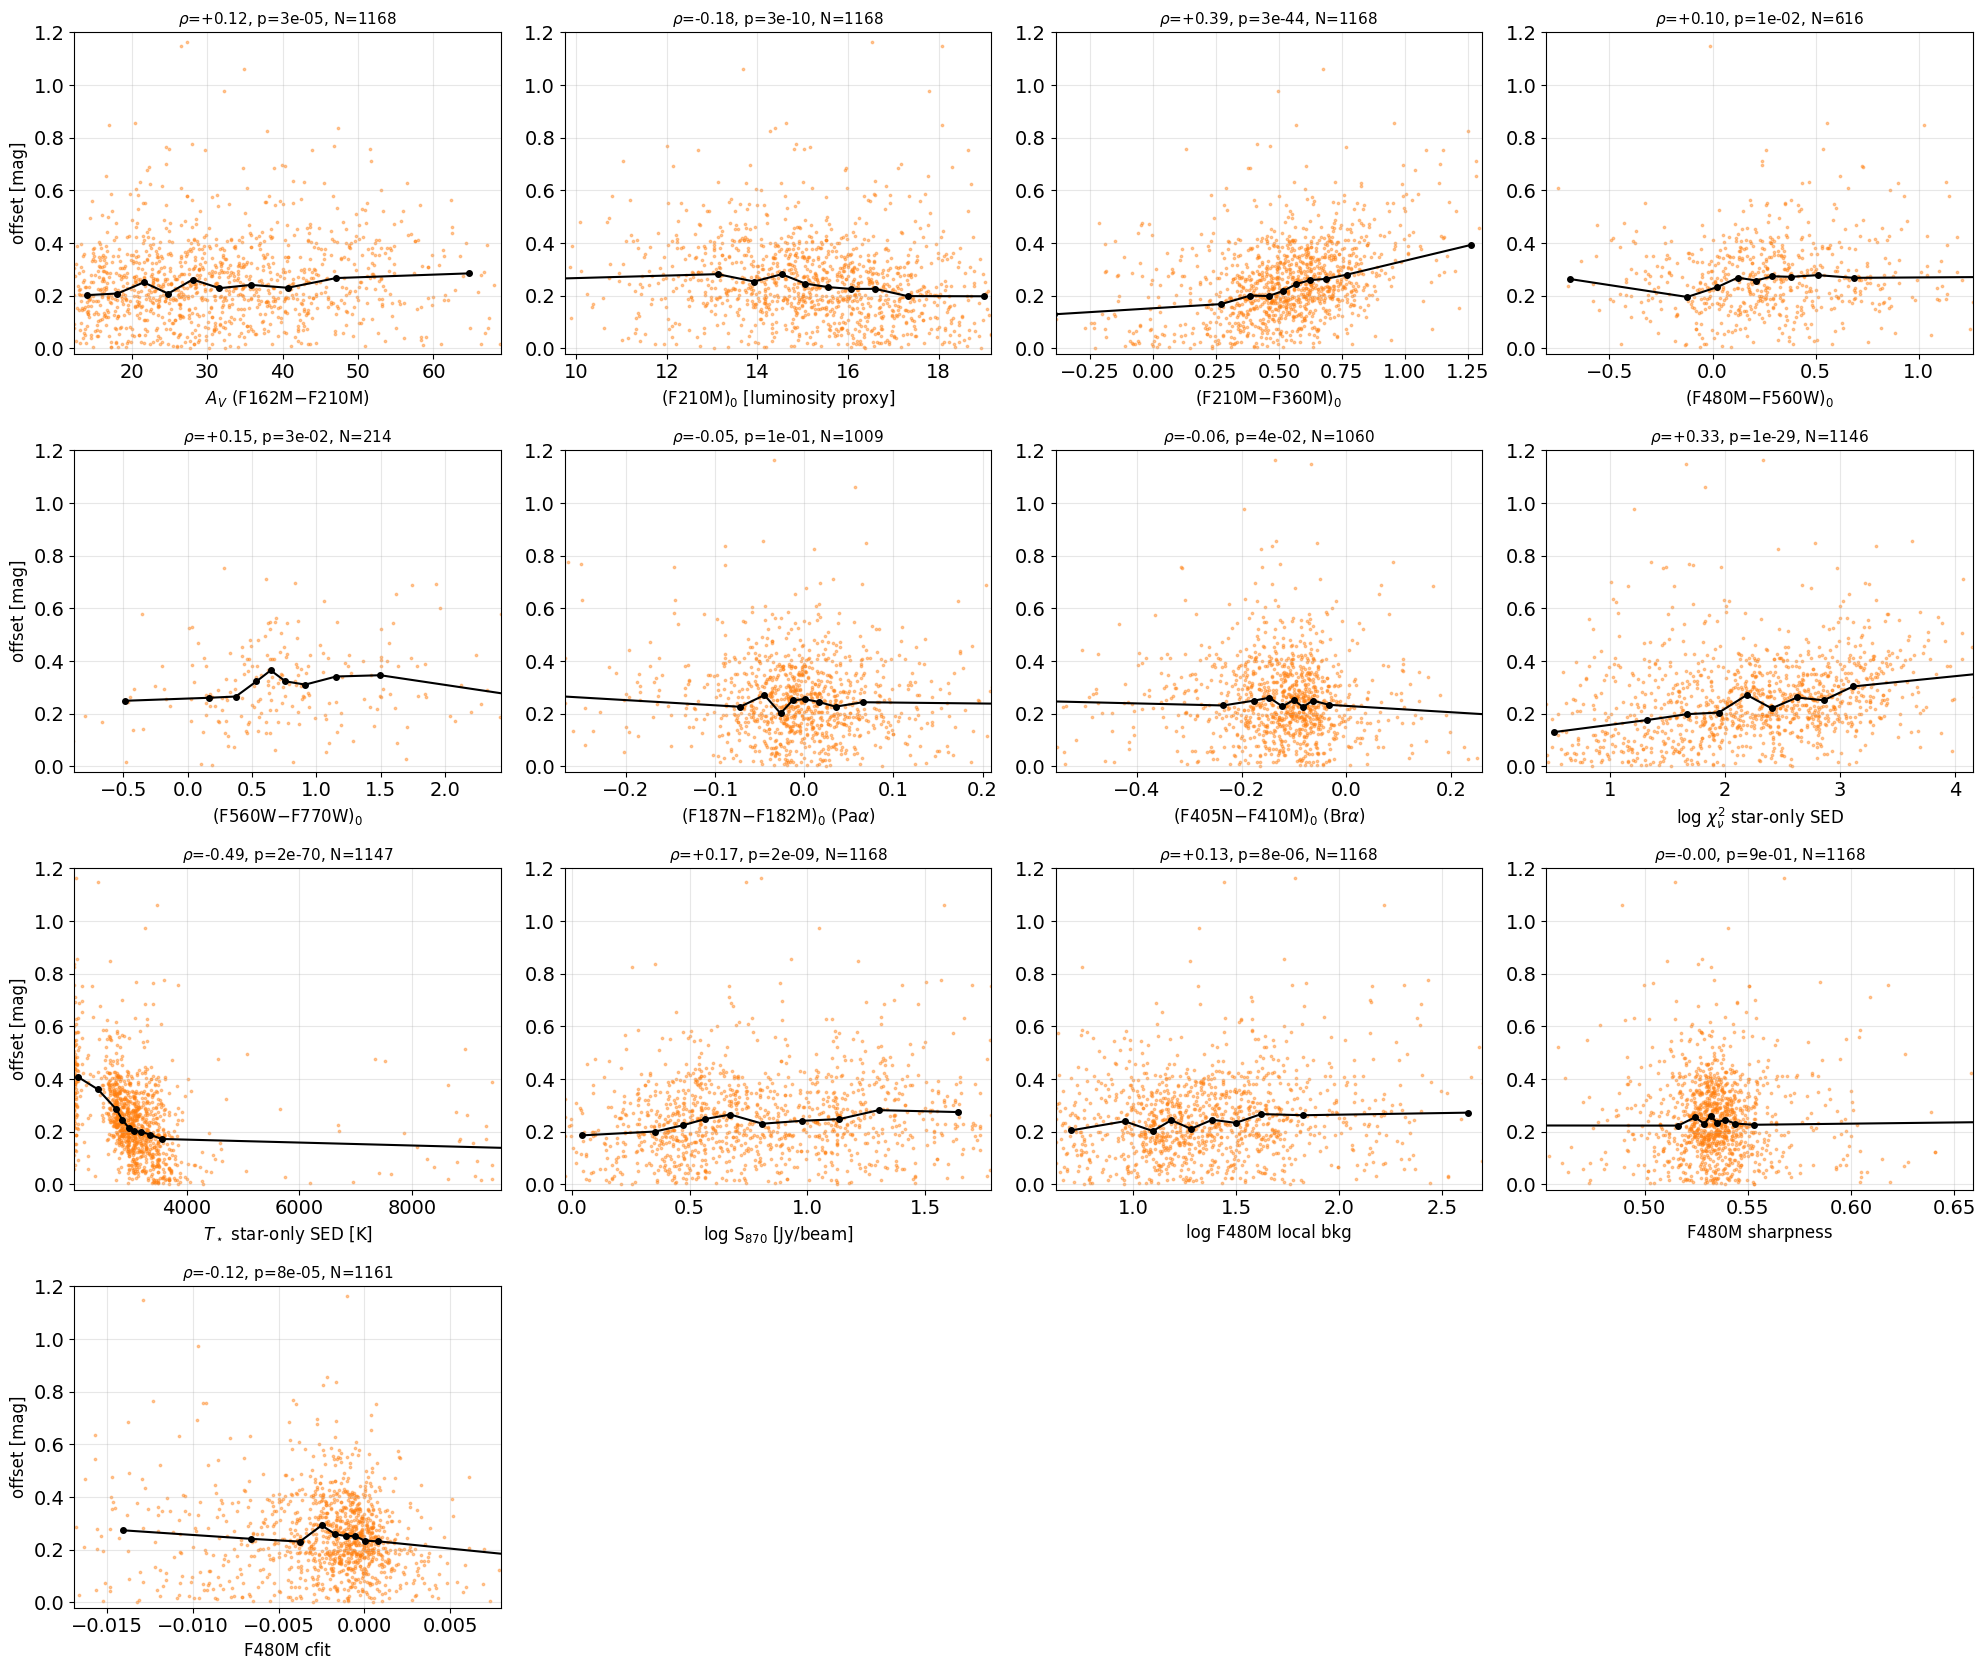

In [11]:
names = [k for k, v in props.items() if np.sum(upper & np.isfinite(v)) >= 20]
ncol = 4
nrow = int(np.ceil(len(names) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(5 * ncol, 4.2 * nrow))
for ax, name in zip(axes.ravel(), names):
    v = props[name]
    m = upper & np.isfinite(v)
    lo, hi = np.nanpercentile(v[m], [1, 99])
    ax.scatter(v[m], offset[m], s=3, c='tab:orange', alpha=0.4)
    xm, ym = running_median(v[m], offset[m], 10)
    ax.plot(xm, ym, 'k-o', ms=4)
    r, p = spearmanr(v[m], offset[m])
    ax.set_title(fr'$\rho$={r:+.2f}, p={p:.0e}, N={m.sum()}', fontsize=11)
    ax.set_xlabel(name, fontsize=12); ax.set_xlim(lo, hi); ax.set_ylim(-0.02, 1.2); ax.grid(alpha=0.3)
for ax in axes[:, 0]:
    ax.set_ylabel('offset [mag]', fontsize=12)
for ax in axes.ravel()[len(names):]:
    ax.axis('off')
plt.tight_layout(); plt.savefig(f'{FIGDIR}/upper_branch_offset_vs_properties_cfit003.png', bbox_inches='tight'); plt.show()


 no envelope: N= 417, median offset=0.223 |       envelope: N= 730, median=0.250 | Mann-Whitney p=1.6e-05
     no disk: N= 221, median offset=0.281 |           disk: N= 926, median=0.231 | Mann-Whitney p=7.0e-06
   no cavity: N= 660, median offset=0.227 | bipolar cavity: N= 487, median=0.258 | Mann-Whitney p=2.1e-06


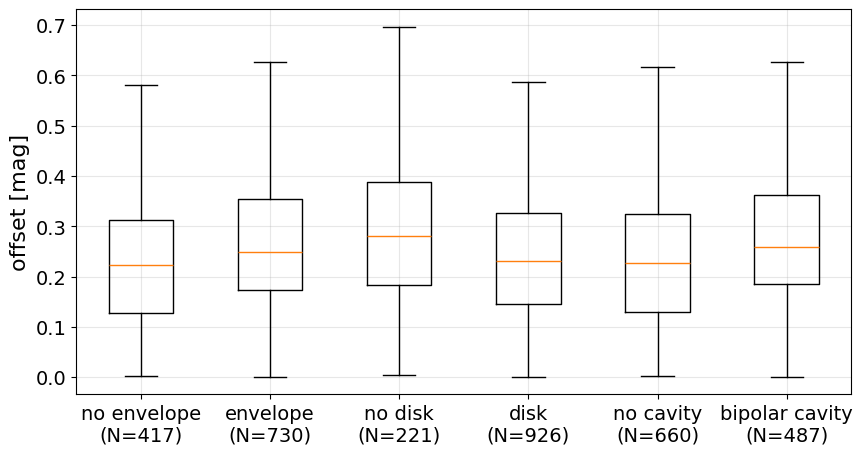

In [12]:
# offset by best-fit YSO geometry (Robitaille 2017 sets)
groups = [('no envelope', upper & has_geo & ~has_env), ('envelope', upper & has_geo & has_env),
          ('no disk', upper & has_geo & ~has_disk), ('disk', upper & has_geo & has_disk),
          ('no cavity', upper & has_geo & ~has_cav), ('bipolar cavity', upper & has_geo & has_cav)]
for i in range(0, 6, 2):
    (l1, m1), (l2, m2) = groups[i], groups[i + 1]
    U, p = mannwhitneyu(offset[m1], offset[m2])
    print(f'{l1:>12s}: N={m1.sum():4d}, median offset={np.median(offset[m1]):.3f} | {l2:>14s}: N={m2.sum():4d}, '
          f'median={np.median(offset[m2]):.3f} | Mann-Whitney p={p:.1e}')
fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot([offset[m] for _, m in groups], labels=[f'{l}\n(N={m.sum()})' for l, m in groups], showfliers=False)
ax.set_ylabel('offset [mag]'); ax.grid(alpha=0.3)
plt.savefig(f'{FIGDIR}/upper_branch_offset_vs_geometry_cfit003.png', bbox_inches='tight'); plt.show()


In [13]:
# the same properties for the lower branch: lower-branch sources sit at negative offsets, so a property that
# tracks dust excess should shift between the branches, and the upper-branch trend should extend it
rows = []
for name, v in props.items():
    mu, ml = upper & np.isfinite(v), lower & np.isfinite(v)
    if mu.sum() < 20 or ml.sum() < 20:
        continue
    U, p = mannwhitneyu(v[mu], v[ml])
    rows.append((name, np.median(v[ml]), np.median(v[mu]), p))
t = Table(rows=rows, names=['property', 'median lower', 'median upper', 'Mann-Whitney p'], dtype=[str, float, float, float])
t['median lower'].format = t['median upper'].format = '.3f'; t['Mann-Whitney p'].format = '.1e'
t.pprint(max_width=-1)


            property             median lower median upper Mann-Whitney p
-------------------------------- ------------ ------------ --------------
           $A_V$ (F162M$-$F210M)       32.473       29.702        3.6e-05
  (F210M)$_0$ [luminosity proxy]       16.245       15.281        2.2e-24
             (F210M$-$F360M)$_0$        0.025        0.539        0.0e+00
             (F480M$-$F560W)$_0$        0.026        0.252        3.5e-17
             (F560W$-$F770W)$_0$        0.094        0.685        1.5e-10
(F187N$-$F182M)$_0$ (Pa$\alpha$)        0.011       -0.007        1.5e-15
(F405N$-$F410M)$_0$ (Br$\alpha$)       -0.088       -0.110        1.3e-12
  log $\chi^2_\nu$ star-only SED        1.515        2.308       1.6e-114
     $T_\star$ star-only SED [K]     3977.000     3028.000        0.0e+00
         log S$_{870}$ [Jy/beam]        0.291        0.732       5.1e-131
             log F480M local bkg        1.039        1.333        5.2e-88
                 F480M sharpness      

## Summary (numbers from the run above)

**Boundary.** The self-trained linear SVM converges to F360M−F480M = 0.124 + 0.242 (F162M−F210M) from every starting labelling tested (hand line, hand line shifted by −0.15…+0.2 mag, 2D GMM). The half-margin is 0.072 mag. The lower branch has Theil–Sen slope 0.236, parallel to the boundary, while CT06 predicts a reddening slope of 0.181.

**(i) Observational effect.** The data disfavor incompleteness as the origin of the gap:
- The gap is clearest for the brightest sources: Ashman D = 2.5 for F480M < 15.5, about 2.4 mag above the F480M number-count turnover. It weakens only in the faintest quartile, where the upper branch holds 8% of sources.
- The offset does correlate with F480M (ρ = −0.30) and F360M (ρ = −0.20) for the upper branch inside a subsample complete in both bands, so truncation at the detection limits does not produce the correlation. The sign is set by the excess itself: extra 3.6–4.8 µm emission brightens those bands. The offset shows no correlation with F162M or F210M (|ρ| < 0.05).
- Filling the gap takes ~1700 sources; 476 A_V > 12 sources lack F360M and/or F480M, and the detection limits allow only ≲100 of those with one missing band to fall in the gap.
- The median color error (0.014–0.047 mag) is smaller than the half-margin at all magnitudes.

**(ii) Physical correlates of the offset (upper branch).**
- The strongest correlates are (F210M−F360M)₀ (ρ = +0.39), the star-only SED fit's χ²_ν (ρ = +0.33), and its T⋆ (ρ = −0.49). The photosphere-only fit absorbs the IR excess by choosing cooler stars, so T⋆ acts here as an excess indicator. All three hold after controlling for A_V.
- Best-fit geometries with an envelope or bipolar cavity have larger offsets than those without (medians 0.250 vs 0.223 and 0.258 vs 0.227). Envelope-only models (no disk) have the largest (0.281 vs 0.231).
- MIRI colors are redder in the upper branch than the lower (F480M−F560W: 0.25 vs 0.03; F560W−F770W: 0.69 vs 0.09). Within the upper branch they correlate only weakly with offset (ρ ≈ 0.10–0.15, below the Bonferroni threshold).
- After dereddening, Paα and Brα narrowband excesses show no correlation with offset.
- The offset correlates with 870 µm intensity (ρ = +0.17) and F480M local background (ρ = +0.13): larger offsets in denser, brighter-nebula regions. This fits younger, more embedded sources, and it also flags possible F480M background-subtraction bias in bright nebulosity.
